### Imports

In [2]:
import pandas as pd
import numpy as np
import os

### load all 8 CSVs

In [3]:
RAW_PATH = "../data/raw/"

all_files = [f for f in os.listdir(RAW_PATH) if f.endswith(".csv")] 

dataframes = []
for file in all_files:
    path = os.path.join(RAW_PATH, file)
    print(f"Reading {file}...")
    df = pd.read_csv(path, encoding="utf-8", low_memory=False)
    dataframes.append(df)

data = pd.concat(dataframes, ignore_index=True)
print(f"\n✅ Total records loaded:{len(data):,}") 


Reading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Reading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Reading Friday-WorkingHours-Morning.pcap_ISCX.csv...
Reading Monday-WorkingHours.pcap_ISCX.csv...
Reading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
Reading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
Reading Tuesday-WorkingHours.pcap_ISCX.csv...
Reading Wednesday-workingHours.pcap_ISCX.csv...

✅ Total records loaded:2,830,743


3. Fix Column Names

In [4]:
data.columns = data.columns.str.strip()
print("\n✅ Column names cleaned.")
print(f"Total columns: {len(data.columns)}")


✅ Column names cleaned.
Total columns: 79


4. Peek at the data

In [5]:
print("Shape:", data.shape)
data.head()

Shape: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


5. See what attacks exists

In [6]:
print("Label Distribution:\n")
print(data["Label"].value_counts())

Label Distribution:

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


6. Fix infinite & NaN values

In [7]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)

print(f"NaN values found: {data.isna().sum().sum():,}")

data.dropna(inplace=True)

print(f"✅ Data cleaned. Remaining records: {len(data):,}") 


NaN values found: 5,734
✅ Data cleaned. Remaining records: 2,827,876


7. Save cleaned data

In [8]:
os.makedirs("../data/processed/", exist_ok=True)

output_path = "../data/processed/ids_cleaned.csv"
data.to_csv(output_path, index=False)

print(f"\n✅ Cleaned data saved to {output_path}")
print(f"Final dataset shape: {data.shape}")


✅ Cleaned data saved to ../data/processed/ids_cleaned.csv
Final dataset shape: (2827876, 79)


### Phase 2 - Feature Engineering & MOdel Preparation

8. Encode the Label Column

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() 

data["Label_encoded"] = le.fit_transform(data["Label"]) 
print("Label encoding mapping: ")
for i, label in enumerate(le.classes_):
    print(f"{i:2d}-> {label}") 


Label encoding mapping: 
 0-> BENIGN
 1-> Bot
 2-> DDoS
 3-> DoS GoldenEye
 4-> DoS Hulk
 5-> DoS Slowhttptest
 6-> DoS slowloris
 7-> FTP-Patator
 8-> Heartbleed
 9-> Infiltration
10-> PortScan
11-> SSH-Patator
12-> Web Attack � Brute Force
13-> Web Attack � Sql Injection
14-> Web Attack � XSS


9. Separate features and target

In [10]:
X = data.drop(columns=["Label", "Label_encoded"])
y = data["Label_encoded"]   

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")   
print(f"Number of classes: {len(y.unique())}")


Features shape: (2827876, 78)
Target shape: (2827876,)
Number of classes: 15


10. Split into train and test sets

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)   

print(f"Training set : {X_train.shape[0]:,},records")
print(f"Test set : {X_test.shape[0]:,},records") 

Training set : 2,262,300,records
Test set : 565,576,records


11. Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 
print("✅ Features scaled Successfully.")
print(f"Training set mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Training set std (should be ~1): {X_train_scaled.std():.4f}") 


✅ Features scaled Successfully.
Training set mean (should be ~0): 0.0000
Training set std (should be ~1): 0.9473


12. Train Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier
import time

print("Training Random Forest Classifier... (this will take 5-15 minutes)")
print("Go grab a coffee ☕️")

start = time.time()
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight="balanced",
    random_state=42, 
    n_jobs=-1
) 

rf_model.fit(X_train_scaled, y_train)
end = time.time()
print(f"\n✅ Random Forest trained in {(end - start)/60:.2f} minutes.") 


Training Random Forest Classifier... (this will take 5-15 minutes)
Go grab a coffee ☕️

✅ Random Forest trained in 2.17 minutes.


13. Evaluate Random Forest

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_rf = rf_model.predict(X_test_scaled) 

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names = le.classes_))

Random Forest Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.94      0.97    454265
                       Bot       0.05      1.00      0.09       391
                      DDoS       1.00      1.00      1.00     25605
             DoS GoldenEye       0.83      0.99      0.90      2059
                  DoS Hulk       0.82      1.00      0.90     46025
          DoS Slowhttptest       0.93      0.99      0.96      1100
             DoS slowloris       0.93      1.00      0.96      1159
               FTP-Patator       1.00      1.00      1.00      1587
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.57      0.73         7
                  PortScan       0.99      1.00      1.00     31761
               SSH-Patator       0.71      1.00      0.83      1180
  Web Attack � Brute Force       0.15      0.50      0.23       301
Web Attack

14. Visualize the Confusion Matrix

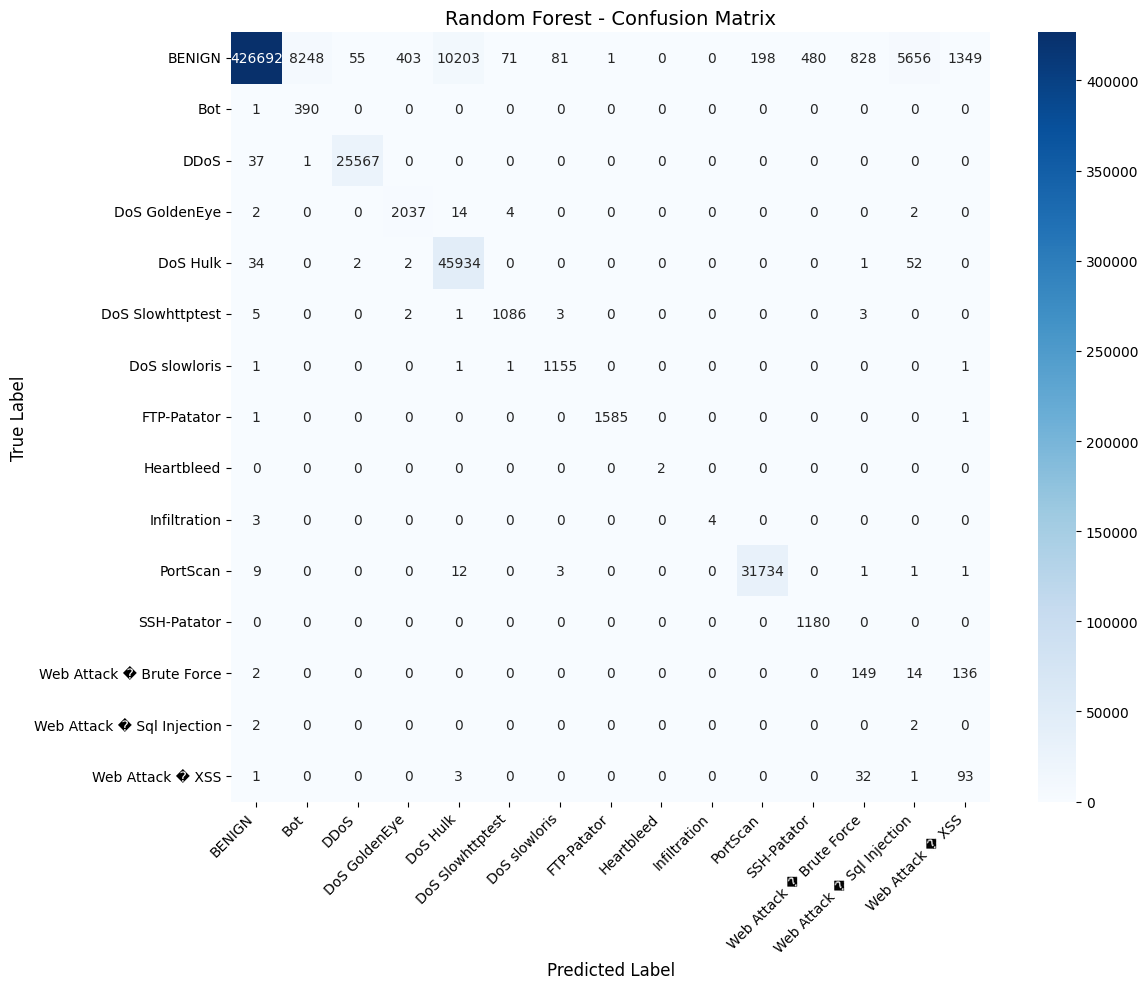

In [15]:
fig, ax = plt.subplots(figsize=(12,10)) 

cm = confusion_matrix(y_test,y_pred_rf)
sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    xticklabels= le.classes_,
    yticklabels= le.classes_,
    cmap = "Blues",
    ax =ax
)

ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Random Forest - Confusion Matrix", fontsize=14)
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show()

15. Feature Importance

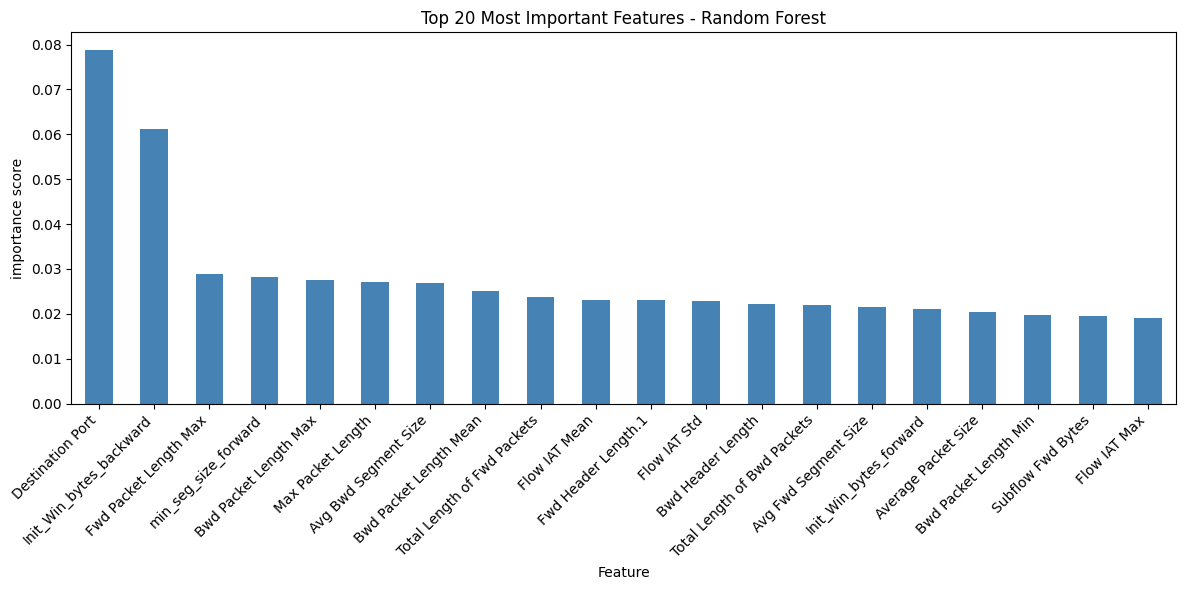


Top 10 features:
Destination Port               0.078777
Init_Win_bytes_backward        0.061282
Fwd Packet Length Max          0.028874
min_seg_size_forward           0.028142
Bwd Packet Length Max          0.027554
Max Packet Length              0.027165
Avg Bwd Segment Size           0.026898
Bwd Packet Length Mean         0.025176
Total Length of Fwd Packets    0.023671
Flow IAT Mean                  0.023140
dtype: float64


In [16]:
importances = pd.Series(
    rf_model.feature_importances_,
    index = X.columns
).sort_values(ascending=False) 

plt.figure(figsize=(12,6))
importances.head(20).plot(kind="bar",color="steelblue")
plt.title("Top 20 Most Important Features - Random Forest")
plt.xlabel("Feature")
plt.ylabel("importance score")
plt.xticks(rotation=45, ha="right") 
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importances.head(10))


16. Train XGBoost

In [17]:
from xgboost import XGBClassifier
import time

print("Training XGBoost Classifier... (this will take 5-15 minutes)")

start = time.time()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_scaled,y_train)

end = time.time()
print(f"\n✅ XGBoost trained in {(end - start)/60:.2f} minutes.")


Training XGBoost Classifier... (this will take 5-15 minutes)


c:\Abhishree\Projects\IDS\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:51:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ XGBoost trained in 4.18 minutes.
